# Capstone Session 12

This notebook is generated from the copied `Capstone_Session_12.pdf` directions and the staged `Dental-Panaromic-Autoencoder.npz` dataset.

## Objective

Build the required denoising autoencoder, train it on the staged dental X-ray data, and compare noisy versus reconstructed outputs.

## Shape Note

The staged arrays are RGB-shaped `(256, 256, 3)`, while the copied PDF also specifies a final decoder layer with 1 filter. This notebook converts the staged RGB arrays to grayscale before training so the model can satisfy the single-channel decoder requirement without inventing a third output convention.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.keras.utils.set_random_seed(42)

BASE_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 12''')
DATA_PATH = BASE_DIR / 'Dental-Panaromic-Autoencoder.npz'
OUTPUTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 12/outputs''')
PLOTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 12/outputs/plots''')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
data = np.load(DATA_PATH)
x_train = data['x_train'].astype('float32') / 255.0 if data['x_train'].max() > 1 else data['x_train'].astype('float32')
x_test = data['x_test'].astype('float32') / 255.0 if data['x_test'].max() > 1 else data['x_test'].astype('float32')
x_train_gray = x_train.mean(axis=-1, keepdims=True)
x_test_gray = x_test.mean(axis=-1, keepdims=True)
noise_factor = 0.2
x_train_noisy = np.clip(x_train_gray + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_gray.shape), 0.0, 1.0)
x_test_noisy = np.clip(x_test_gray + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_gray.shape), 0.0, 1.0)
print({'x_train': x_train.shape, 'x_train_gray': x_train_gray.shape, 'x_test': x_test.shape, 'x_test_gray': x_test_gray.shape})

{'x_train': (92, 256, 256, 3), 'x_train_gray': (92, 256, 256, 1), 'x_test': (24, 256, 256, 3), 'x_test_gray': (24, 256, 256, 1)}


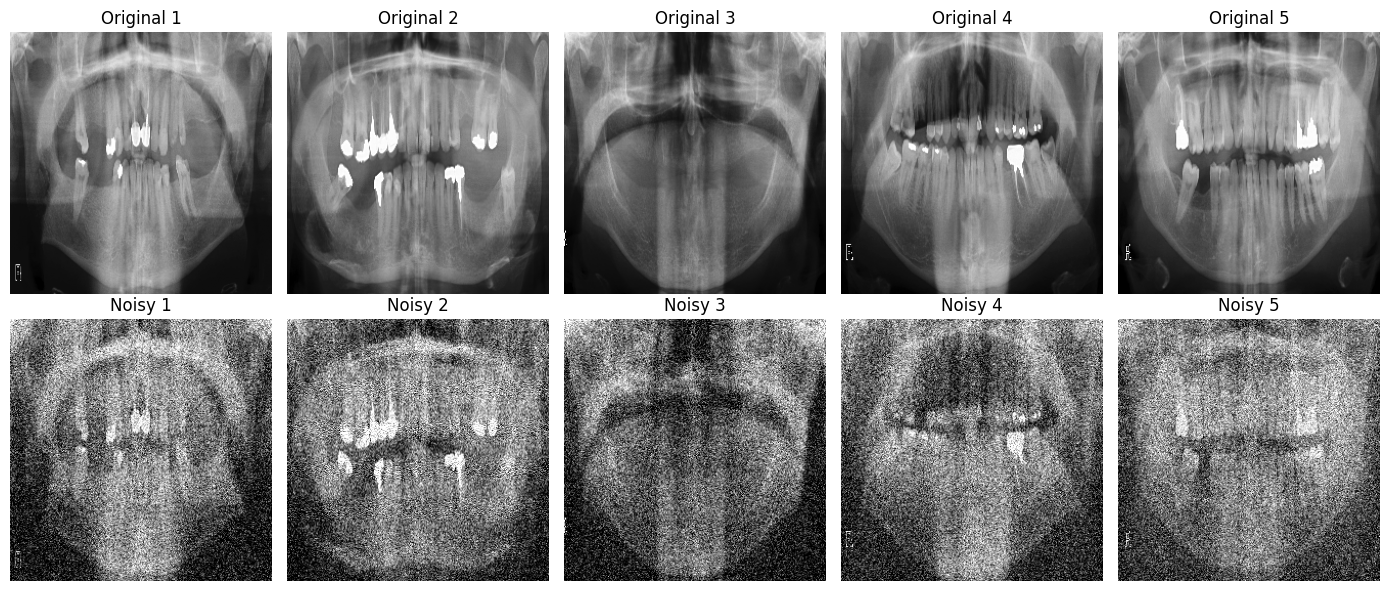

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for index in range(5):
    axes[0, index].imshow(x_train_gray[index].squeeze(), cmap='gray')
    axes[0, index].axis('off')
    axes[0, index].set_title(f'Original {index + 1}')
    axes[1, index].imshow(x_train_noisy[index].squeeze(), cmap='gray')
    axes[1, index].axis('off')
    axes[1, index].set_title(f'Noisy {index + 1}')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'original_vs_noisy_train.png', dpi=150)
plt.show()
plt.close(fig)

In [4]:
class Denoise(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(256, 256, 1)),
            tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2),
            tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, activation='relu', padding='same'),
            tf.keras.layers.Conv2DTranspose(64, kernel_size=3, strides=2, activation='relu', padding='same'),
            tf.keras.layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same'),
        ])

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = Denoise()
autoencoder.compile(optimizer='adam', loss=tf.keras.losses.MeanSquaredError(), metrics=['mae'])

In [5]:
history = autoencoder.fit(
    x_train_noisy,
    x_train_gray,
    epochs=50,
    batch_size=8,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_gray),
    verbose=0,
)
pd.DataFrame(history.history).tail()

,loss,mae,val_loss,val_mae
45,0.002327,0.033945,0.002332,0.034123
46,0.002356,0.034250,0.002390,0.034695
47,0.002378,0.034472,0.002322,0.034076
48,0.002378,0.034481,0.002315,0.034097
49,0.002320,0.033975,0.002282,0.033775


In [6]:
evaluation = autoencoder.evaluate(x_test_noisy, x_test_gray, verbose=0)
encoded_images = autoencoder.encoder(x_test_noisy).numpy()
decoded_images = autoencoder.decoder(encoded_images).numpy()
print({'test_loss': float(evaluation[0]), 'test_mae': float(evaluation[1]), 'encoded_shape': encoded_images.shape, 'decoded_shape': decoded_images.shape})

{'test_loss': 0.0022817247081547976, 'test_mae': 0.033774904906749725, 'encoded_shape': (24, 64, 64, 32), 'decoded_shape': (24, 256, 256, 1)}


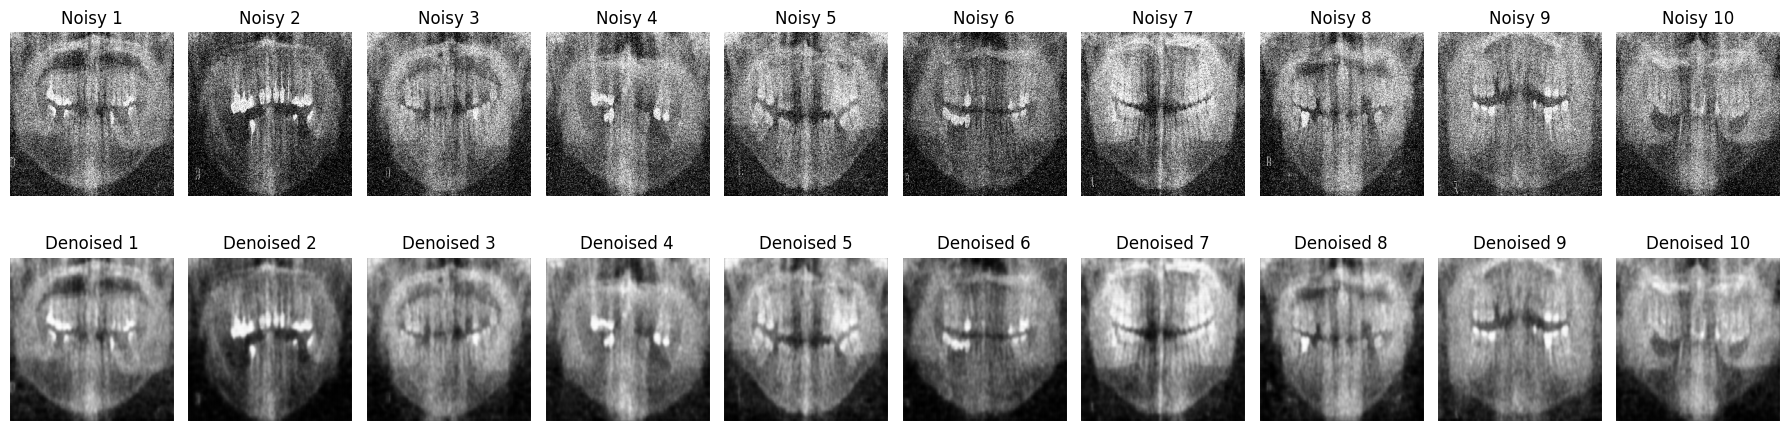

In [7]:
fig, axes = plt.subplots(2, 10, figsize=(18, 5))
for index in range(10):
    axes[0, index].imshow(x_test_noisy[index].squeeze(), cmap='gray')
    axes[0, index].axis('off')
    axes[0, index].set_title(f'Noisy {index + 1}')
    axes[1, index].imshow(decoded_images[index].squeeze(), cmap='gray')
    axes[1, index].axis('off')
    axes[1, index].set_title(f'Denoised {index + 1}')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'noisy_vs_denoised_test.png', dpi=150)
plt.show()
plt.close(fig)

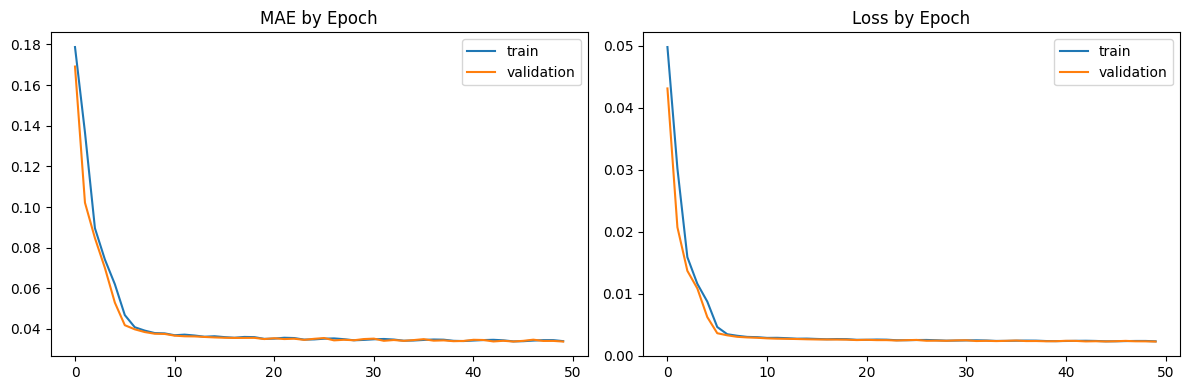

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['mae'], label='train')
axes[0].plot(history.history['val_mae'], label='validation')
axes[0].set_title('MAE by Epoch')
axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss by Epoch')
axes[1].legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'training_history.png', dpi=150)
plt.show()
plt.close(fig)

In [9]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUTS_DIR / 'session_12_training_history.csv', index=False)
summary = {
    'original_shapes': {'x_train': list(x_train.shape), 'x_test': list(x_test.shape)},
    'grayscale_shapes': {'x_train_gray': list(x_train_gray.shape), 'x_test_gray': list(x_test_gray.shape)},
    'noise_factor': noise_factor,
    'test_loss': float(evaluation[0]),
    'test_mae': float(evaluation[1]),
    'encoded_shape': list(encoded_images.shape),
    'decoded_shape': list(decoded_images.shape),
}
with open(OUTPUTS_DIR / 'session_12_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary

{'original_shapes': {'x_train': [92, 256, 256, 3],
  'x_test': [24, 256, 256, 3]},
 'grayscale_shapes': {'x_train_gray': [92, 256, 256, 1],
  'x_test_gray': [24, 256, 256, 1]},
 'noise_factor': 0.2,
 'test_loss': 0.0022817247081547976,
 'test_mae': 0.033774904906749725,
 'encoded_shape': [24, 64, 64, 32],
 'decoded_shape': [24, 256, 256, 1]}